In [13]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage
from dotenv import load_dotenv

from langgraph.checkpoint.memory import MemorySaver

load_dotenv()


True

In [14]:
from langgraph.graph.message import add_messages

# this import is used for adding a reducer function. Although operator.add also works but this inbuilt function is more optimised to handle state chnages .

In [15]:
class chatstate(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]


In [16]:
chat_model = ChatOpenAI(model='gpt-4o-mini')

In [17]:
def chat_bot(state: chatstate):

    messages = state['messages']

    response = chat_model.invoke(messages)

    return {'messages': [response]}

In [18]:
graph = StateGraph(chatstate)

In [19]:
checkpointer = MemorySaver()
graph.add_node("chat",chat_bot)


graph.add_edge(START, "chat")
graph.add_edge("chat",END)

In [20]:
chatbot = graph.compile(checkpointer=checkpointer)

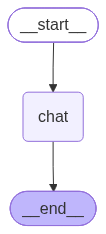

In [21]:
from IPython.display import Image
Image(chatbot.get_graph().draw_mermaid_png())

In [23]:
thread_id = "1"

while True:

    user_message = input("Type your message: ")

    print('User:', user_message)

    if user_message.strip().lower() in ["exit","quit"]:
        break
    config = {'configurable': {"thread_id": thread_id}}
    response = chatbot.invoke({"messages": [HumanMessage(content=user_message)]}, config=config)

    print('AI:', response['messages'][-1].content)

User: hi, my name is amitoj

AI: Hi Amitoj! How can I assist you today?
User: what is my name
AI: Your name is Amitoj. How can I help you today?
User: exit

